In [56]:
%pip install --upgrade  langchain langchain-google-genai "langchain[docarray]" faiss-cpu pypdf

In [57]:
pip install -U langchain-google-genai google-generativeai

In [58]:

import os
import requests
from PIL import Image


In [59]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Markdown

In [60]:
!pip install -U  langchain-community "docarray"

In [61]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.vectorstores import DocArrayInMemorySearch
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [62]:
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
os.environ['GOOGLE_API_KEY'] = GOOGLE_API_KEY

In [63]:
#List of model checking
from google import genai
client = genai.Client()
models = client.models.list()
for m in models:
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025

In [64]:
from langchain_google_genai import ChatGoogleGenerativeAI

def load_model(model_name):
    if model_name == "gemini-2.5-flash":
        llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
    else:
        llm = ChatGoogleGenerativeAI(model="gemini-2.5-pro")
    return llm

model_text = load_model("gemini-2.5-flash")

response = model_text.invoke("Tell me a very funny joke")

print(response.content)

Okay, here's a classic that often gets a good groan-laugh:

An invisible man walks into a bar.

He says, "Ouch!"


In [65]:
def get_image(url,filename,extension):
  content = requests.get(url).content
  with open(f'/content/{filename}.{extension}', 'wb') as f:
    f.write(content)
  image = Image.open(f"/content/{filename}.{extension}")
  image.show()
  return image

In [67]:
image = get_image("https://rukminim2.flixcart.com/image/1536/1536/xif0q/jean/a/s/6/28-men-loose-fit-blue-jeans-7jyi-flaying-original-imahd93xypxmat32.jpeg?q=90", "jeans", ".png")

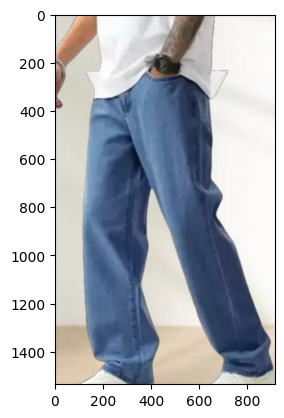

In [68]:
plt.imshow(image)
plt.show()

In [87]:
vision_model=load_model("gemini-2.5-flash")

In [88]:
import base64

def encode_image(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

image_base64 = encode_image("/content/jeans..png")
message = HumanMessage(content=[
    {"type": "text", "text": "Describe this image"},
    {
        "type": "image_url",
        "image_url": f"data:image/jpeg;base64,{image_base64}"
    }
])

response = vision_model.invoke([message])

In [89]:
response.content

"The image features a person from approximately the chest down, dressed in casual attire, standing against a plain, light-colored background.\n\nThe person is wearing a plain white short-sleeved t-shirt, the bottom edge of which is visible, slightly covering the waistband of their jeans. The most prominent item of clothing is a pair of loose-fitting, wide-leg, light to medium blue denim jeans. The jeans appear to be quite baggy, with visible seams running down the legs and some natural creasing from the fabric's drape. They pool slightly over the person's feet, where white sneakers are visible.\n\nOn the person's right arm (viewer's left), a black wristwatch is worn, and extensive dark tattoos are visible on the forearm, extending upwards. This hand is casually tucked into the front pocket of the jeans. On the left arm (viewer's right), a light-colored, possibly beaded or woven, bracelet is visible on the wrist, with the hand partially out of frame.\n\nThe person is standing in a relax

In [115]:
from langchain_community.document_loaders.csv_loader import CSVLoader

loader = CSVLoader(file_path="/content/processed_products.csv")

data = loader.load()

print(data[0].page_content)
docs = data

Product_ID: 1
Product_Title: Ernie Ball Mondo Slinky Nickelwound Electric Guitar Strings 10.5-52 Gauge
Description: ['Product Description', 'Ernie Ball Mondo Slinkys are ideal for players who prefer a heavier gauge with a little less tension on the plain strings (E, B, G). These electric guitar strings are precision manufactured to the highest standards and most exacting specifications to ensure consistency, optimum performance, and long life. Mondo Slinky wound strings are made from nickel-plated steel wire wrapped around a hex-shaped steel core wire while the plain strings are made of specially tempered tin-plated high-carbon steel, resulting in that iconic Slinky feel and tone that players have relied on for decades. Mondo Slinky gauges are .0105 .0135 .0175 .030 .042 .052.', 'From the Manufacturer', 'Mondo Slinky strings are ideal for players who prefer a heavier low end with only a slight difference in tension on the plain strings. Gauge combination: 10. 5, 13. 5, 17. 5, 30, 42, 5

In [93]:
pip install -U langchain-text-splitters

In [109]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [116]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20)
texts = text_splitter.split_documents(docs)

In [117]:
len(texts)

107248

In [120]:
embeddings = GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")

In [121]:
vectorstore = FAISS.from_documents(texts,embedding=embeddings)

GoogleGenerativeAIError: Error embedding content (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/text-embedding-004 is not found for API version v1beta, or is not supported for embedContent. Call ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}

In [123]:
!pip install langchain-huggingface
from langchain_huggingface import HuggingFaceEmbeddings


In [125]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [126]:
vectorstore = FAISS.from_documents(docs,embedding=embeddings)

In [130]:
que = vectorstore.similarity_search_with_score(
    query='best laptop stand?',
    k=2
)

In [131]:
que

[(Document(id='8edeb44e-d638-4238-94b6-0eb5c160ecc2', metadata={'source': '/content/processed_products.csv', 'row': 2687}, page_content='Product_ID: 2688\nProduct_Title: RockJam Tripod Laptop Stand, Projector Stand, & DJ Rack. 20" x 16" Plate & Adjustable Height 25" to 44"\nDescription: [\'The RockJam Laptop stand is crafted from quality components to make the most durable and adaptable laptop stand on the market today.\']\nCategory: Musical Instruments\nPrice: 32.99\nRating: 4.2\nRating_Count: 738\nStore: RockJam\nfeature_list: ["[\'Strong: made from steel this laptop stand is made to last and easily withstand The rigors of everyday life\', \'Multi-purpose: This stand be used for various needs, equally adept as a laptop stand, temporary standing desk or a projector stand, this device can service a number of needs\', \'Stable: The tripod design on this stand offers a huge amount of stability and sustaining the weight of your devices comfortably\', \'Adjustable: the height of this stand

In [134]:
retriever = vectorstore.as_retriever()

In [135]:
retriever.invoke("smartphone.")

[Document(id='fc3124b4-79f1-4a5e-a939-3a4c5684537f', metadata={'source': '/content/processed_products.csv', 'row': 1604}, page_content='Product_ID: 1605\nProduct_Title: LOCOLO 5-Pack Mini Microphone with Omnidirectional Stereo Mic for Voice Recording, Portable Microphone Chatting and Singing Compatible with Smartphone\nDescription: []\nCategory: Musical Instruments\nPrice: 13.93\nRating: 3.8\nRating_Count: 1108\nStore: LOCOLO\nfeature_list: ["[\'Mini handheld condenser microphone for voice recording & internet chatting, and phone calls.\', \'Just plug and record anytime, anywhere without an external power supply; Lightweight, high quality, and easy to take along.\', \'It is just a mini-phone microphone(please check the size carefully before you place it, thank you.) it can be compatible with an earphone plug with 3.5mm of the smartphone.\', \'Cute, lightweight, and mini design, easy to carry(wiring length: 59.05inch; Microphone length: 2.28 inches.\', \'Please note that the Android pho

In [139]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [138]:
prompt = PromptTemplate(
    template="""Based on the given context:\n {context}

{query}


Provide brief information with respect to query.
    """,
    input_variables=['context','query']
)

In [141]:
parser = StrOutputParser()
rag_chain = (
    {"context": retriever, "query":RunnablePassthrough()} | prompt | vision_model | parser
)

In [142]:
rag_chain.invoke("Laptop stand")

'Laptop stands, as described in the documents, are typically tripod-based and multi-purpose, suitable for holding laptops, projectors, DJ equipment, and mixers. They are characterized by their adjustable height, with ranges varying from approximately 25 inches to 55 inches, and often feature an angle/tilt adjustable tray with raised edges for secure device placement. Tray sizes vary, for example, 20" x 16" or 15.3" x 12.2". Constructed from durable materials like steel, these stands are designed to be portable, lightweight, and foldable for easy transport and storage.'

In [143]:

full_chain = (
    RunnablePassthrough() | vision_model | StrOutputParser() | rag_chain
)

In [160]:
url = "https://rukminim2.flixcart.com/image/1600/2140/xif0q/laptop-stand/n/n/t/250-laptop-stand-7-angles-adjustable-aluminum-portable-desktop-original-imaghpuxbxqnhzgb.jpeg?q=60"

In [164]:
image = get_image(url, "laptopstand", "png")

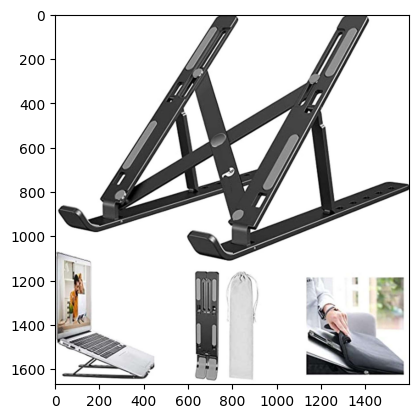

In [163]:
plt.imshow(image)
plt.show()

In [170]:
import base64

def encode_image(path):
    with open(path, "rb") as f:
        return "data:image/png;base64," + base64.b64encode(f.read()).decode()

In [173]:
image = encode_image("/content/laptopstand.png")
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Provide information on given product image Brand and model.",
        },  # You can optionally provide text parts
        {"type": "image_url", "image_url": image},
    ]
)

In [174]:
result = full_chain.invoke([message])

In [175]:
result

'I cannot directly view the image you are referring to. However, based on the provided product documents, the products described are **adjustable, foldable, portable tripod stands** designed for laptops, projectors, DJ equipment, music notes, and other electronic devices.\n\nCommon features across these products include:\n*   **Adjustable Height:** Ranging from approximately 22.8 to 63.5 inches.\n*   **Portability:** Foldable designs and detachable components for easy transport.\n*   **Stability:** Often feature a triangular tripod structure, sturdy metal trays, and sometimes safety latches.\n*   **Versatility:** Suitable for various settings like home, office, stage, studio, and events.\n*   **Accessories:** Many include gooseneck phone holders, elastic belts, and sponge pads for device security.\n\nThe specific brands mentioned in the documents are YouMeekc, DECOSIS, RockJam, and Pyle.'